In [5]:
import os
import sys
sys.path.append(os.getcwd())
print(os.getcwd())
import numpy as np
import math
import scipy.sparse as sp
import helpers.ProblemData as ProblemData
import matplotlib.pyplot as plt

c:\Users\linco\Quantum\Quantum-NTE


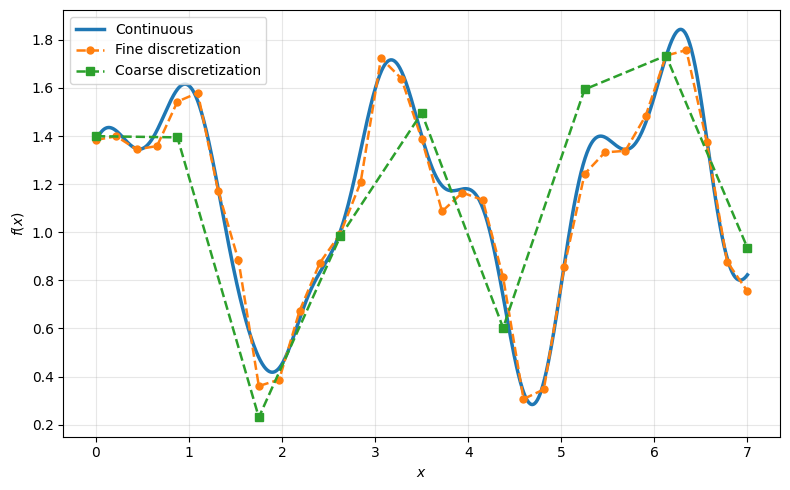

In [107]:
# Reproducible randomness
np.random.seed(412)

# Smooth "continuous" function with dips/bumps
def f(x):
    return (
        1.2
        + 0.35 * np.sin(2.4 * x)
        + 0.18 * np.cos(6.0 * x)
        - 0.55 * np.exp(-((x - 2.0) / 0.35) ** 2)
        - 0.40 * np.exp(-((x - 4.7) / 0.45) ** 2)
        + 0.30 * np.exp(-((x - 6.4) / 0.30) ** 2)
    )

# Domains
n_fine = 32
n_coarse = 8
x_cont = np.linspace(0, 7, 1000)   # "continuous"
x_fine = np.linspace(0, 7, n_fine + 1)     # fine discretization
x_coarse = np.linspace(0, 7, n_coarse + 1)    # coarse discretization

# Exact values
y_cont = f(x_cont)
y_fine_exact = f(x_fine)
y_coarse_exact = f(x_coarse)

# Add random discretization error
fine_error = np.random.normal(0, 0.05, size=len(x_fine))
coarse_error = np.random.normal(0, 0.20, size=len(x_coarse))

y_fine = y_fine_exact + fine_error
y_coarse = y_coarse_exact + coarse_error

# Plot
plt.figure(figsize=(8, 5))

# Continuous curve
plt.plot(
    x_cont,
    y_cont,
    linewidth=2.5,
    label="Continuous"
)

# Fine discretization
plt.plot(
    x_fine,
    y_fine,
    "o--",
    linewidth=1.8,
    markersize=5,
    label="Fine discretization"
)

# Coarse discretization
plt.plot(
    x_coarse,
    y_coarse,
    "s--",
    linewidth=1.8,
    markersize=6,
    label="Coarse discretization"
)

plt.xlabel(r"$x$")
plt.ylabel(r"$f(x)$")
#plt.title("Continuous Function and Discretized Approximations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

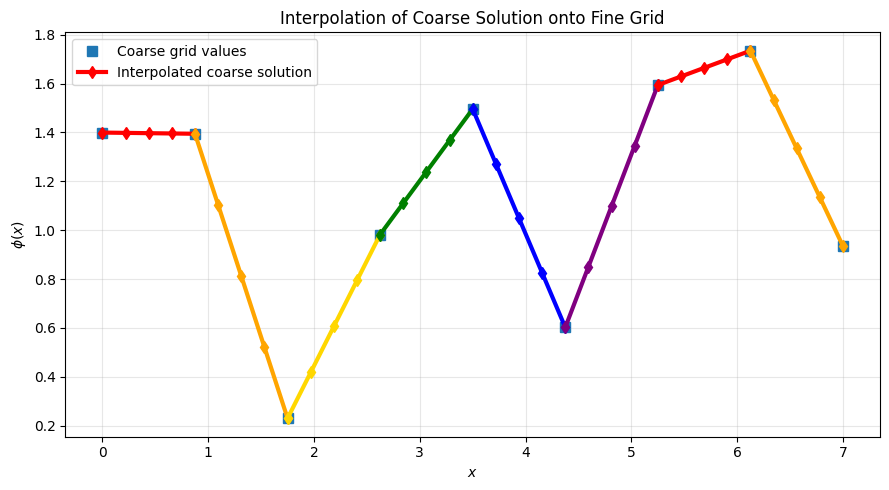

In [82]:
y_coarse_interp = np.interp(x_fine, x_coarse, y_coarse)
# Plot
plt.figure(figsize=(9, 5))

# Original coarse points
plt.plot(
    x_coarse,
    y_coarse,
    "s",
    markersize=7,
    label="Coarse grid values"
)

# Colors for different regions
segment_colors = [
    "red",
    "orange",
    "gold",
    "green",
    "blue",
    "purple"
]

# Plot interpolated curve in colored segments
num_segments = n_coarse

# Indices splitting the fine grid into segments
split_indices = np.linspace(0, len(x_fine) - 1, num_segments + 1, dtype=int)

for i in range(num_segments):
    start = split_indices[i]
    end = split_indices[i + 1] + 1  # include endpoint

    plt.plot(
        x_fine[start:end],
        y_coarse_interp[start:end],
        "d-",
        linewidth=3,
        color=segment_colors[i % len(segment_colors)],
        label="Interpolated coarse solution" if i == 0 else None
    )

plt.xlabel(r"$x$")
plt.ylabel(r"$\phi(x)$")
plt.title("Interpolation of Coarse Solution onto Fine Grid")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

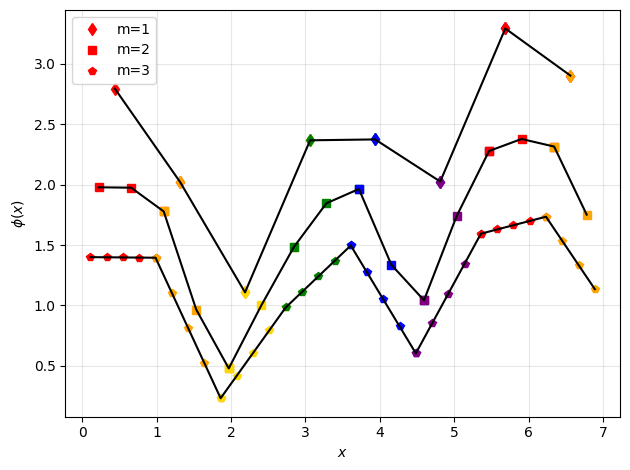

In [112]:
x_coarse_1 = np.linspace(0+7/n_coarse/2, 7-+7/n_coarse/2, n_coarse)    # coarse discretization
y_coarse_prob_1 = [np.sqrt(sum([y_coarse_interp[i]**2 for i in range(int(j*n_fine/n_coarse), int((j+1)*n_fine/n_coarse))])) for j in range(n_coarse)]


segment_colors = [
    "red",
    "orange",
    "gold",
    "green",
    "blue",
    "purple"
]

# Plot interpolated curve in colored segments
num_segments = n_coarse

# Indices splitting the fine grid into segments
split_indices = np.linspace(0, len(x_coarse_1), num_segments + 1, dtype=int)

for i in range(num_segments):
    start = split_indices[i]
    end = split_indices[i + 1] + 1  # include endpoint

    plt.plot(
        x_coarse_1[start:end],
        y_coarse_prob_1[start:end],
        "d",
        linewidth=3,
        color=segment_colors[i % len(segment_colors)],
        label="m=1" if i == 0 else None
    )

plt.plot(x_coarse_1, y_coarse_prob_1, '-k')
plt.xlabel(r"$x$")
plt.ylabel(r"$\phi(x)$")
#plt.title("Interpolation of Coarse Solution onto Fine Grid")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()



x_coarse_2 = np.linspace(0+7/n_coarse/4, 7-+7/n_coarse/4, 2*n_coarse)    # coarse discretization
y_coarse_prob_2 = [np.sqrt(sum([y_coarse_interp[i]**2 for i in range(int(j*n_fine/n_coarse/2), int((j+1)*n_fine/n_coarse/2))])) for j in range(2*n_coarse)]


segment_colors = [
    "red",
    "orange",
    "gold",
    "green",
    "blue",
    "purple"
]

# Plot interpolated curve in colored segments
num_segments = n_coarse

# Indices splitting the fine grid into segments
split_indices = np.linspace(0, len(x_coarse_2), num_segments + 1, dtype=int)

for i in range(num_segments):
    start = split_indices[i]
    end = split_indices[i + 1] + 1  # include endpoint

    plt.plot(
        x_coarse_2[start:end],
        y_coarse_prob_2[start:end],
        "s",
        linewidth=3,
        color=segment_colors[i % len(segment_colors)],
        label="m=2" if i == 0 else None
    )

plt.plot(x_coarse_2, y_coarse_prob_2, '-k')
plt.xlabel(r"$x$")
plt.ylabel(r"$\phi(x)$")
#plt.title("Interpolation of Coarse Solution onto Fine Grid")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()



x_coarse_3 = np.linspace(0+7/n_coarse/8, 7-+7/n_coarse/8, 4*n_coarse)    # coarse discretization
y_coarse_prob_3 = [np.sqrt(sum([y_coarse_interp[i]**2 for i in range(int(j*n_fine/n_coarse/4), int((j+1)*n_fine/n_coarse/4))])) for j in range(4*n_coarse)]

segment_colors = [
    "red",
    "orange",
    "gold",
    "green",
    "blue",
    "purple"
]

# Plot interpolated curve in colored segments
num_segments = n_coarse

# Indices splitting the fine grid into segments
split_indices = np.linspace(0, len(x_coarse_3), num_segments + 1, dtype=int)

for i in range(num_segments):
    start = split_indices[i]
    end = split_indices[i + 1] + 1  # include endpoint

    plt.plot(
        x_coarse_3[start:end],
        y_coarse_prob_3[start:end],
        "p",
        linewidth=3,
        color=segment_colors[i % len(segment_colors)],
        label="m=3" if i == 0 else None
    )

plt.plot(x_coarse_3, y_coarse_prob_3, '-k')
plt.xlabel(r"$x$")
plt.ylabel(r"$\phi(x)$")
#plt.title("Interpolation of Coarse Solution onto Fine Grid")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()



plt.show()